<a href="https://colab.research.google.com/github/HazaraTechLab/50StarUps.ipynb/blob/master/Supervised_Learning_til_e_mail_filtrering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1. Imports og alle nødvendige python biblioteker**

In [1]:
import numpy as np
import pandas as pd

from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns


**2. Data loading**

In [2]:
uploaded = files.upload()

import zipfile
with zipfile.ZipFile("archive.zip", "r") as zip_ref:
    zip_ref.extractall()

df = pd.read_csv("email.csv")


Saving archive.zip to archive.zip


 **3. Data cleaning**

In [3]:
# Fjern dubletter
df = df.drop_duplicates()

# Rens tekst
df['Message'] = df['Message'].str.lower().str.replace(r'[^\w\s]', '', regex=True)

# Konverter labels
df['Category'] = df['Category'].map({'ham':0, 'spam':1})

# Fjern evt. NaN
df = df.dropna(subset=['Category'])


**4. Feature Engineering – TF-IDF**

In [4]:
X = df['Message']
y = df['Category']

vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(X)


**5. Datasplit (80/20)**

In [26]:
# Første split: 80% træning, 20% midlertidigt
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Andet split: 10% validering, 10% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)




**6. Modeltræning**

In [31]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# SVM
svm = SVC(kernel='linear')
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)





**7. Evaluering**

In [24]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

print("\nLogistic Regression:")
print(classification_report(y_test, y_pred_lr))

print("\nSVM:")
print(classification_report(y_test, y_pred_svm))





Logistic Regression Accuracy: 0.9321705426356589
SVM Accuracy: 0.9728682170542635

Logistic Regression:
              precision    recall  f1-score   support

         0.0       0.93      1.00      0.96       448
         1.0       0.95      0.51      0.67        68

    accuracy                           0.93       516
   macro avg       0.94      0.76      0.81       516
weighted avg       0.93      0.93      0.92       516


SVM:
              precision    recall  f1-score   support

         0.0       0.97      1.00      0.98       448
         1.0       0.97      0.82      0.89        68

    accuracy                           0.97       516
   macro avg       0.97      0.91      0.94       516
weighted avg       0.97      0.97      0.97       516



**8. Confusion Matrix (én model)**

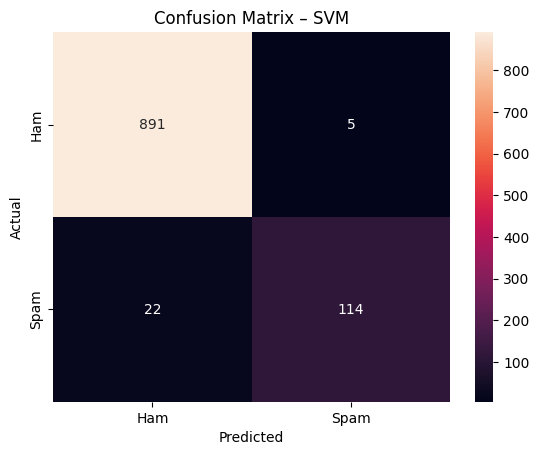

In [8]:
cm = confusion_matrix(y_test, y_pred_svm)

sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Ham','Spam'],
            yticklabels=['Ham','Spam'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – SVM")
plt.show()


In [11]:
# Use your custom data to make prediction
def predict_spam_or_ham(text):
    text_tfidf = vectorizer.transform([text])   # TF-IDF på ny tekst
    prediction = lr.predict(text_tfidf)         # brug Logistic Regression
    return 'spam' if prediction[0] == 1 else 'ham'


In [16]:
def predict_spam_or_ham_svm(text):
    text_tfidf = vectorizer.transform([text])
    prediction = svm.predict(text_tfidf)
    return "spam" if prediction[0] == 1 else "ham"


In [17]:
# Example 1: usage
email = "Congratulations, you've won a lottery of $1000! Call now."
result = predict_spam_or_ham(email)
print(f"The email is: {result}")


The email is: ham


In [18]:
# Example 2: usage
email = "I will go there any fight back!"
result = predict_spam_or_ham(email)
print(f"The email is: {result}")

The email is: ham


In [19]:
# example 3
email = "FREE MONEY WIN CASH NOW CLICK LINK URGENT"
print(predict_spam_or_ham(email))


spam


In [20]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred_lr)
print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 93.22%
